In [1]:
import numpy as np
import pandas as pd
import geopandas
import contextily as cx
import matplotlib.pyplot as plt

## Ingest data

In [ ]:
addresses_raw = geopandas.read_file('data/raw/allegheny_AddressPoints.zip')

In [ ]:
# copy to edit
addresses_c = addresses_raw.set_index('FEATURE_KE')
addresses_c = addresses_c.drop(columns=['COMMENT', 'POINT_X', 'POINT_Y'])

In [142]:
addresses_c.head()

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,COMMENT,EDIT_DATE,EDIT_USER,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
110,110,0,21111,1,ACTIVE,None,106,None,None,None,...,None,2018-08-21,t096517,EAMS,None,106 SAXONWALD LN,None,0.0,0.0,POINT (1338298.2 383997.4)
128,128,0,19699,1,ACTIVE,None,143,None,None,None,...,None,2026-01-08,T096517,EAMS,None,143 RANA LN,None,0.0,0.0,POINT (1358246.2 477693.3)
129,129,0,19699,1,ACTIVE,None,155,None,None,None,...,None,2026-01-08,T096517,EAMS,None,155 RANA LN,None,0.0,0.0,POINT (1358239.9 477443)
131,131,0,20532,1,ACTIVE,None,233,None,None,None,...,None,2026-01-08,T096517,EAMS,None,233 ROSE CIR,None,0.0,0.0,POINT (1358246.3 477730.6)
142,142,0,20532,1,ACTIVE,None,206,None,None,None,...,None,2026-01-08,T096517,EAMS,None,206 ROSE CIR,None,0.0,0.0,POINT (1358239.4 477876.6)


In [143]:
addresses_c.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 655286 entries, 110 to 723715
Data columns (total 31 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ADDRESS_ID  655286 non-null  int64         
 1   PARENT_ID   655286 non-null  int64         
 2   STREET_ID   655286 non-null  int64         
 3   ADDRESS_TY  655286 non-null  int32         
 4   STATUS      655286 non-null  object        
 5   ADDR_NUM_P  51 non-null      object        
 6   ADDR_NUM    655286 non-null  object        
 7   ADDR_NUM_S  4216 non-null    object        
 8   ST_PREMODI  0 non-null       object        
 9   ST_PREFIX   31883 non-null   object        
 10  ST_PRETYPE  0 non-null       object        
 11  ST_NAME     655286 non-null  object        
 12  ST_TYPE     652208 non-null  object        
 13  ST_POSTMOD  20 non-null      object        
 14  UNIT_TYPE   133015 non-null  object        
 15  UNIT        132370 non-null  object        
 1

In [144]:
addresses_c.columns

Index(['ADDRESS_ID', 'PARENT_ID', 'STREET_ID', 'ADDRESS_TY', 'STATUS',
       'ADDR_NUM_P', 'ADDR_NUM', 'ADDR_NUM_S', 'ST_PREMODI', 'ST_PREFIX',
       'ST_PRETYPE', 'ST_NAME', 'ST_TYPE', 'ST_POSTMOD', 'UNIT_TYPE', 'UNIT',
       'FLOOR', 'MUNICIPALI', 'COUNTY', 'STATE', 'ZIP_CODE', 'COMMENT',
       'EDIT_DATE', 'EDIT_USER', 'SOURCE', 'EXP_FLAG', 'FULL_ADDRE',
       'ST_SUFFIX', 'POINT_X', 'POINT_Y', 'geometry'],
      dtype='object')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


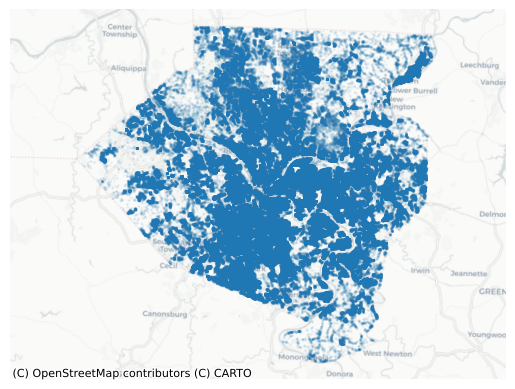

In [ ]:
ax = addresses_c.plot(markersize=1, alpha=0.05)
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron)
ax.set_adjustable('datalim')
ax.set_axis_off()

## Examining duplicate addresses

Many addresses appear multiple times. In some cases, they are the exact same address, varying only by data identifiers (e.g. address_id) and geometry (slight variations in longitude/latitude, but still on the same building/plot). Others appear to be separate locations with matching street names (typically across municipalities).

In [145]:
addresses_c['FULL_ADDRE'].value_counts().head(1000)

FULL_ADDRE
1130 PERRY HWY      24
255 E OHIO ST       21
10441 PERRY HWY     15
3080 SMALLMAN ST    14
1701 LINCOLN HWY    14
                    ..
307 LINCOLN AVE      3
546 LINCOLN AVE      3
205 LINCOLN AVE      3
613 8TH ST           3
609 8TH ST           3
Name: count, Length: 1000, dtype: int64

In [146]:
len(addresses_c[addresses_c.duplicated(subset='FULL_ADDRE')])

12323

In [147]:
addresses_c[addresses_c['FULL_ADDRE'] == '1130 PERRY HWY'].iloc[:, 0:28].head()

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,COUNTY,STATE,ZIP_CODE,COMMENT,EDIT_DATE,EDIT_USER,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
364058,364058,0,18657,7,ACTIVE,None,1130,None,None,None,...,ALLEGHENY,PA,15237,None,2025-02-25,T116489,EAMS,NU,1130 PERRY HWY,None
711522,711521,0,18657,2,ACTIVE,None,1130,None,None,None,...,ALLEGHENY,PA,15237,None,2025-02-25,T116489,EAMS,NU,1130 PERRY HWY,None
711523,711522,0,18657,2,ACTIVE,None,1130,None,None,None,...,ALLEGHENY,PA,15237,None,2025-02-25,T116489,EAMS,NU,1130 PERRY HWY,None
711524,711523,0,18657,2,ACTIVE,None,1130,None,None,None,...,ALLEGHENY,PA,15237,None,2025-02-25,T116489,EAMS,NU,1130 PERRY HWY,None
711525,711524,0,18657,2,ACTIVE,None,1130,None,None,None,...,ALLEGHENY,PA,15237,None,2025-02-25,T116489,EAMS,NU,1130 PERRY HWY,None


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


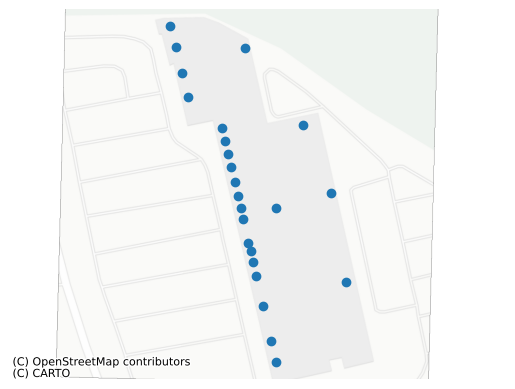

In [ ]:
ax = addresses_c[addresses_c['FULL_ADDRE'] == '1130 PERRY HWY'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron)
ax.set_adjustable('datalim')
ax.set_axis_off()

In [148]:
addresses_c[addresses_c['FULL_ADDRE'] == '609 8TH ST'].iloc[:, 0:28]

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,COUNTY,STATE,ZIP_CODE,COMMENT,EDIT_DATE,EDIT_USER,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
213175,213175,0,635,1,ACTIVE,None,609,None,None,None,...,ALLEGHENY,PA,15139,None,2026-01-04,T096517,EAMS,None,609 8TH ST,None
320024,320024,0,637,1,ACTIVE,None,609,None,None,None,...,ALLEGHENY,PA,15140,None,2026-01-04,T096517,EAMS,None,609 8TH ST,None
408121,408121,0,633,0,ACTIVE,None,609,None,None,None,...,ALLEGHENY,PA,15045,None,2013-06-13,None,UNVERIFIED,None,609 8TH ST,None


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


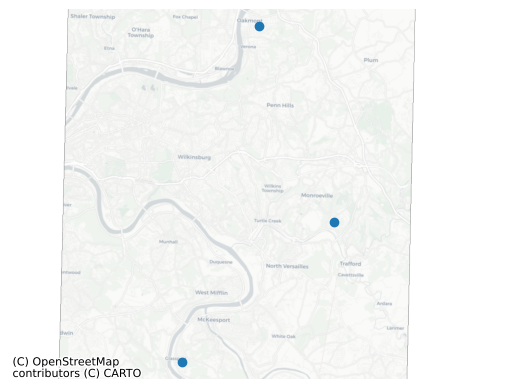

In [ ]:
ax = addresses_c[addresses_c['FULL_ADDRE'] == '609 8TH ST'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron)
ax.set_adjustable('datalim')
ax.set_axis_off()

### Combined address fields

Combined address field includes municipality and zip code in addition to street address. Duplicates of this field may be considered 'true' duplicates.

In [153]:
addresses_c.head().iloc[:, 17:27]

,MUNICIPALI,COUNTY,STATE,ZIP_CODE,COMMENT,EDIT_DATE,EDIT_USER,SOURCE,EXP_FLAG,FULL_ADDRE
FEATURE_KE,,,,,,,,,,
110,CASTLE SHANNON BOROUGH,ALLEGHENY,PA,15234,None,2018-08-21,t096517,EAMS,None,106 SAXONWALD LN
128,RICHLAND TOWNSHIP,ALLEGHENY,PA,15044,None,2026-01-08,T096517,EAMS,None,143 RANA LN
129,RICHLAND TOWNSHIP,ALLEGHENY,PA,15044,None,2026-01-08,T096517,EAMS,None,155 RANA LN
131,RICHLAND TOWNSHIP,ALLEGHENY,PA,15044,None,2026-01-08,T096517,EAMS,None,233 ROSE CIR
142,RICHLAND TOWNSHIP,ALLEGHENY,PA,15044,None,2026-01-08,T096517,EAMS,None,206 ROSE CIR


In [155]:
addresses_c['COMBINED_ADDR'] = addresses_c['FULL_ADDRE'] + ' ' + addresses_c['MUNICIPALI'] + ' ' + addresses_c['ZIP_CODE']

In [156]:
addresses_c.iloc[:5, [26, 31, 30]]

,FULL_ADDRE,COMBINED_ADDR,geometry
FEATURE_KE,,,
110,106 SAXONWALD LN,106 SAXONWALD LN CASTLE SHANNON BOROUGH 15234,POINT (1338298.2 383997.4)
128,143 RANA LN,143 RANA LN RICHLAND TOWNSHIP 15044,POINT (1358246.2 477693.3)
129,155 RANA LN,155 RANA LN RICHLAND TOWNSHIP 15044,POINT (1358239.9 477443)
131,233 ROSE CIR,233 ROSE CIR RICHLAND TOWNSHIP 15044,POINT (1358246.3 477730.6)
142,206 ROSE CIR,206 ROSE CIR RICHLAND TOWNSHIP 15044,POINT (1358239.4 477876.6)


In [157]:
addresses_c['COMBINED_ADDR'].value_counts()[addresses_c['COMBINED_ADDR'].value_counts() > 1]

COMBINED_ADDR
1130 PERRY HWY ROSS TOWNSHIP 15237                      24
255 E OHIO ST CITY OF PITTSBURGH 15212                  21
10441 PERRY HWY MCCANDLESS TOWNSHIP 15090               15
3045 PYRAMID AVE BRENTWOOD BOROUGH 15227                14
3080 SMALLMAN ST CITY OF PITTSBURGH 15201               14
                                                        ..
1155 WASHINGTON PIKE STE 1 COLLIER TOWNSHIP 15017        2
129 BELLA VISTA DR BALDWIN BOROUGH 15236                 2
5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044           2
131 BELLA VISTA DR BALDWIN BOROUGH 15236                 2
3958 MONROEVILLE BLVD MONROEVILLE MUNICIPALITY 15146     2
Name: count, Length: 973, dtype: int64

In [158]:
len(addresses_c[addresses_c.duplicated(subset='COMBINED_ADDR')])

1483

NOTE: "Full Address" field also includes 'unit' details such as apartment number, which results in many addresses associated with a single address point. Ignoring these details may be necessary to match certain property records to address points later on (i.e. if the property data entry does not include unit details).

Adding secondary 'no unit' columns for later usage.

In [159]:
addresses_c[addresses_c['UNIT'].notna()]['COMBINED_ADDR'].sort_values().head()

FEATURE_KE
710012    1 1ST ST APT 101 OAKMONT BOROUGH 15139
710013    1 1ST ST APT 102 OAKMONT BOROUGH 15139
710014    1 1ST ST APT 103 OAKMONT BOROUGH 15139
710015    1 1ST ST APT 104 OAKMONT BOROUGH 15139
710016    1 1ST ST APT 105 OAKMONT BOROUGH 15139
Name: COMBINED_ADDR, dtype: object

In [160]:
addresses_c['FULL_ADDR_NOUNIT'] = addresses_c[['ADDR_NUM', 'ST_PREFIX', 'ST_NAME', 'ST_TYPE', 'ST_POSTMOD', 'ST_SUFFIX']].fillna('').astype(str).agg(lambda x: ' '.join(x[x != '']), axis=1)

In [161]:
addresses_c['COMBINED_ADDR_NOUNIT'] = addresses_c['FULL_ADDR_NOUNIT'] + ' ' + addresses_c['MUNICIPALI'] + ' ' + addresses_c['ZIP_CODE']

In [162]:
addresses_c['COMBINED_ADDR_NOUNIT'].value_counts().head()

COMBINED_ADDR_NOUNIT
250 CEDAR RIDGE DR MONROEVILLE MUNICIPALITY 15146    734
3333 FORBES AVE CITY OF PITTSBURGH 15213             397
1420 CENTRE AVE CITY OF PITTSBURGH 15219             381
112 WASHINGTON PL CITY OF PITTSBURGH 15219           355
320 FORT DUQUESNE BLVD CITY OF PITTSBURGH 15222      347
Name: count, dtype: int64

### Examining 'true' duplicates

Some duplicate addresses are fully duplicated, i.e. geometry (and possibly identifiers) are identical or nearly identical

In [163]:
addresses_c[addresses_c['COMBINED_ADDR'] == '131 BELLA VISTA DR BALDWIN BOROUGH 15236']

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
710129,710128,0,30239,2,ACTIVE,None,131,None,None,None,...,MUNICIPALITY,None,131 BELLA VISTA DR,None,0.0,0.0,POINT (1343444.244 373927.495),131 BELLA VISTA DR BALDWIN BOROUGH 15236,131 BELLA VISTA DR,131 BELLA VISTA DR BALDWIN BOROUGH 15236
710129,710128,0,30239,2,ACTIVE,None,131,None,None,None,...,MUNICIPALITY,None,131 BELLA VISTA DR,None,0.0,0.0,POINT (1343444.244 373927.495),131 BELLA VISTA DR BALDWIN BOROUGH 15236,131 BELLA VISTA DR,131 BELLA VISTA DR BALDWIN BOROUGH 15236


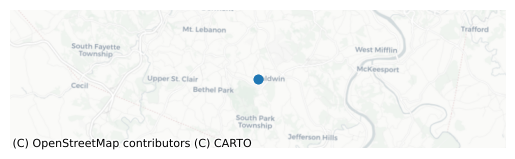

In [ ]:
ax = addresses_c[addresses_c['COMBINED_ADDR'] == '131 BELLA VISTA DR BALDWIN BOROUGH 15236'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

This example has nearly identical geometry; referring to same plot but differing by a few meters

In [164]:
addresses_c[addresses_c['COMBINED_ADDR'] == '5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044']

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
422644,422644,0,25924,7,ACTIVE,None,5354,None,None,None,...,EAMS,DUP,5354 WILLIAM FLYNN HWY,None,0.0,0.0,POINT (1359172.8 475525.2),5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044,5354 WILLIAM FLYNN HWY,5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044
713830,713829,0,25924,2,ACTIVE,None,5354,None,None,None,...,EAMS,NU,5354 WILLIAM FLYNN HWY,None,0.0,0.0,POINT (1359198.408 475509.141),5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044,5354 WILLIAM FLYNN HWY,5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044


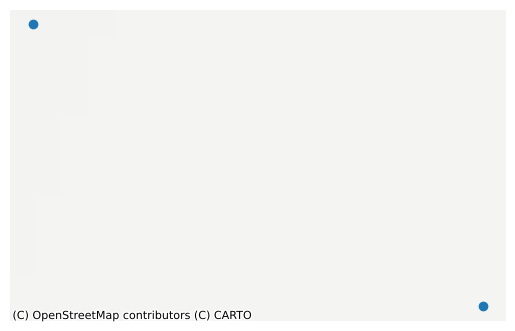

In [ ]:
ax = addresses_c[addresses_c['COMBINED_ADDR'] == '5354 WILLIAM FLYNN HWY RICHLAND TOWNSHIP 15044'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron, zoom=10)
ax.set_axis_off()

Other duplicates are very close but appear refer to slightly different plots

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


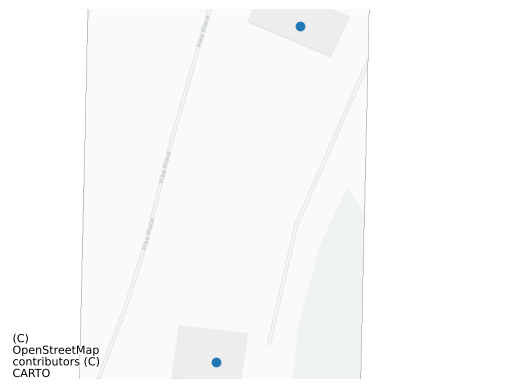

In [ ]:
ax = addresses_c[addresses_c['COMBINED_ADDR'] == '3958 MONROEVILLE BLVD MONROEVILLE MUNICIPALITY 15146'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron)
ax.set_adjustable('datalim')
ax.set_axis_off()

## Handling duplicates

### Exact duplicates

Entries with duplicate combined_addr and geometry can be ignored (only first instance kept)

In [165]:
addresses_c[addresses_c.duplicated(subset=['COMBINED_ADDR', 'geometry'], keep=False)].iloc[:5, -4:-2]

,geometry,COMBINED_ADDR
FEATURE_KE,,
1342,POINT (1354135.8 410919.8),3600 FORBES AVE CITY OF PITTSBURGH 15213
1342,POINT (1354135.8 410919.8),3600 FORBES AVE CITY OF PITTSBURGH 15213
1342,POINT (1354135.8 410919.8),3600 FORBES AVE CITY OF PITTSBURGH 15213
1342,POINT (1354135.8 410919.8),3600 FORBES AVE CITY OF PITTSBURGH 15213
1342,POINT (1354135.8 410919.8),3600 FORBES AVE CITY OF PITTSBURGH 15213


In [166]:
len(addresses_c[addresses_c.duplicated(subset=['COMBINED_ADDR', 'geometry'])])

403

In [167]:
addresses_c = addresses_c.drop_duplicates(subset=['COMBINED_ADDR', 'geometry'])

In [168]:
len(addresses_c)

654883

### Duplicates with variant geometry

In [169]:
addr_dupe_geo = addresses_c[addresses_c.duplicated(subset='COMBINED_ADDR', keep=False)]
addr_dupe_geo.iloc[:5, -4:-2]

,geometry,COMBINED_ADDR
FEATURE_KE,,
2866,POINT (1355944.285 410373.489),51 BOUNDARY ST CITY OF PITTSBURGH 15213
4022,POINT (1348948 403401.9),2201 SALISBURY ST CITY OF PITTSBURGH 15210
4517,POINT (1356029.5 410416.7),51 BOUNDARY ST CITY OF PITTSBURGH 15213
5664,POINT (1374345.325 370917.767),1700 WASHINGTON BLVD PORT VUE BOROUGH 15133
5688,POINT (1395650.7 446514.6),1309 FREEPORT RD HARMAR TOWNSHIP 15024


In [170]:
len(addr_dupe_geo)

1725

In [171]:
addr_dupe_geo['COMBINED_ADDR'].nunique()

645

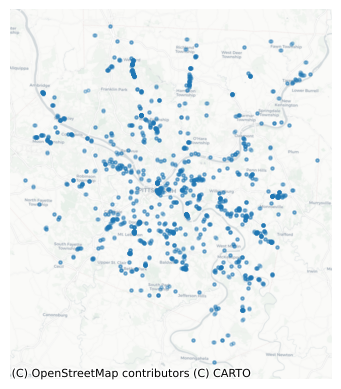

In [ ]:
ax = addr_dupe_geo.plot(markersize=5, alpha=0.3)
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

In [172]:
addr_dupe_geo['COMBINED_ADDR'].value_counts()

COMBINED_ADDR
1130 PERRY HWY ROSS TOWNSHIP 15237                  24
255 E OHIO ST CITY OF PITTSBURGH 15212              21
10441 PERRY HWY MCCANDLESS TOWNSHIP 15090           15
1701 LINCOLN HWY NORTH VERSAILLES TOWNSHIP 15137    14
3045 PYRAMID AVE BRENTWOOD BOROUGH 15227            14
                                                    ..
1630 GREENTREE RD SCOTT TOWNSHIP 15220               2
2891 WEST LIBERTY AVE DORMONT BOROUGH 15216          2
2895 WEST LIBERTY AVE DORMONT BOROUGH 15216          2
2885 WEST LIBERTY AVE DORMONT BOROUGH 15216          2
408 LYSLE BLVD CITY OF MCKEESPORT 15132              2
Name: count, Length: 645, dtype: int64

Once again, some duplicate points seem to be extremely close; interchangeable

In [173]:
addr_dupe_geo[addr_dupe_geo['COMBINED_ADDR'] == '408 LYSLE BLVD CITY OF MCKEESPORT 15132']

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
556895,556895,0,14271,2,ACTIVE,None,408,None,None,None,...,EAMS,DUP,408 LYSLE BLVD,None,0.0,0.0,POINT (1379715.737 377951.186),408 LYSLE BLVD CITY OF MCKEESPORT 15132,408 LYSLE BLVD,408 LYSLE BLVD CITY OF MCKEESPORT 15132
678960,678959,0,14271,2,ACTIVE,None,408,None,None,None,...,EAMS,DUP,408 LYSLE BLVD,None,0.0,0.0,POINT (1379735.268 377952.488),408 LYSLE BLVD CITY OF MCKEESPORT 15132,408 LYSLE BLVD,408 LYSLE BLVD CITY OF MCKEESPORT 15132


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


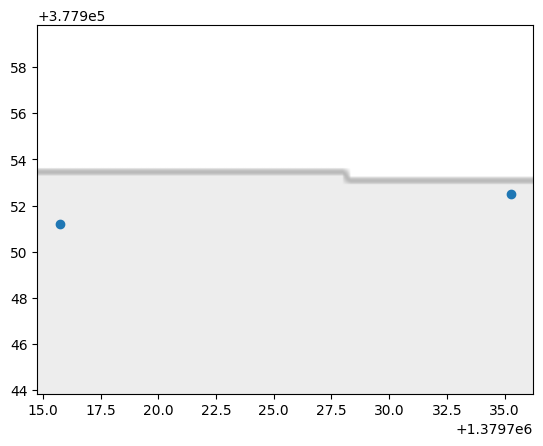

In [ ]:
ax = addr_dupe_geo[addr_dupe_geo['COMBINED_ADDR'] == '408 LYSLE BLVD CITY OF MCKEESPORT 15132'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron, zoom=20, attribution=False)
ax.set_adjustable('datalim')

#### Calculating duplicate point distances

By observing geometric distance between duplicate address points, we can identify which variations are neglible and which may require further investigation

In [11]:
from scipy.spatial.distance import pdist

In [174]:
addr_dupe_geo['geometry'].get_coordinates().head()

,x,y
FEATURE_KE,,
2866,1.355944e+06,410373.489216
4022,1.348948e+06,403401.900140
4517,1.356030e+06,410416.700415
5664,1.374345e+06,370917.766618
5688,1.395651e+06,446514.600332


In [176]:
addr_dupe_geo.loc[:, 'geo_x'] = addr_dupe_geo['geometry'].x
addr_dupe_geo.loc[:, 'geo_y'] = addr_dupe_geo['geometry'].y

In [18]:
def max_dist(group):
    # coord pair matrix
    coords = np.column_stack((group.geometry.x, group.geometry.y))
    # distances between all coord pairs
    dists = pdist(coords)
    
    return dists.max()

In [177]:
addr_dupe_dist = addr_dupe_geo.groupby('COMBINED_ADDR').apply(max_dist, include_groups=False)
addr_dupe_dist.head()

COMBINED_ADDR
1 AMERICAN ST CITY OF PITTSBURGH 15207                    42.628161
1 QUAKER VILLAGE SHOPPING CTR LEETSDALE BOROUGH 15056    148.389708
1 RIVER RD MCKEES ROCKS BOROUGH 15136                    201.967325
1 SELDON PL CITY OF PITTSBURGH 15234                     112.292285
1 TECUMSEH ST CITY OF PITTSBURGH 15207                   329.893206
dtype: float64

Previous example has very low distance (values in feet)

In [178]:
addr_dupe_dist.loc['408 LYSLE BLVD CITY OF MCKEESPORT 15132']

np.float64(19.574489122717026)

This example from before (where geometric variation may indeed be problematic) has greater distance

In [179]:
addr_dupe_dist.loc['3958 MONROEVILLE BLVD MONROEVILLE MUNICIPALITY 15146']

np.float64(236.10809932372018)

Sorting by distance shows us most 'concerning' instances

In [180]:
addr_dupe_dist.sort_values(ascending=False)

COMBINED_ADDR
200 NEVILLE RD NEVILLE TOWNSHIP 15225            2509.417385
16 SPRING ST ETNA BOROUGH 15223                  1626.898443
2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129    1408.119424
2007 FOXWOOD DR FORWARD TOWNSHIP 15037           1303.918320
2100 WASHINGTON PIKE SCOTT TOWNSHIP 15106        1286.145378
                                                    ...     
418 BEAVER ST SEWICKLEY BOROUGH 15143               7.646706
413 SMITHFIELD ST CITY OF PITTSBURGH 15222          6.834051
304 E 8TH AVE HOMESTEAD BOROUGH 15120               6.272422
2144 ARDMORE BLVD FOREST HILLS BOROUGH 15221        5.080166
539 GREENFIELD AVE CITY OF PITTSBURGH 15207         4.989807
Length: 645, dtype: float64

#### Investigating distant points

This appears to be a large water treatment facility, hence the address extending to multiple buildings over a large area.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


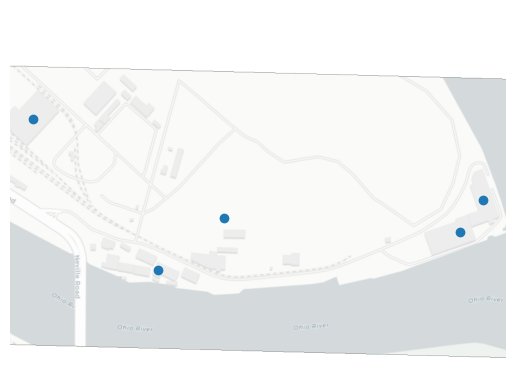

In [ ]:
ax = addresses_c[addresses_c['COMBINED_ADDR'] == '200 NEVILLE RD NEVILLE TOWNSHIP 15225'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_adjustable('datalim')
ax.set_axis_off()

This instance is more strange; the same address refers to completely different buildings in the same general area. The only differing field to compare by is edit date (might be preferable to use newest entry).

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


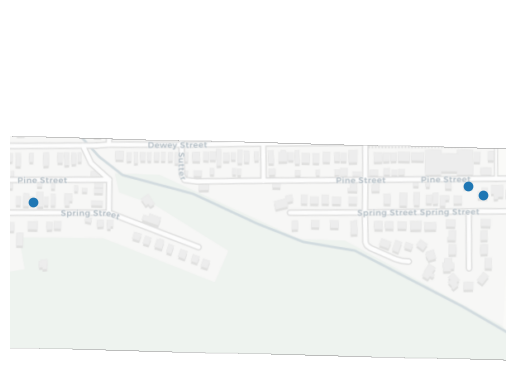

In [ ]:
ax = addresses_c[addresses_c['COMBINED_ADDR'] == '16 SPRING ST ETNA BOROUGH 15223'].plot()
cx.add_basemap(ax, crs=addresses_c.crs, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_adjustable('datalim')
ax.set_axis_off()

In [184]:
addresses_c[addresses_c['COMBINED_ADDR'] == '16 SPRING ST ETNA BOROUGH 15223'].iloc[:, 22:]

,EDIT_DATE,EDIT_USER,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT
FEATURE_KE,,,,,,,,,,,,
48518,2018-07-13,T096517,EAMS,DUP,16 SPRING ST,None,0.0,0.0,POINT (1355309.9 433650),16 SPRING ST ETNA BOROUGH 15223,16 SPRING ST,16 SPRING ST ETNA BOROUGH 15223
52470,2016-09-17,t096517,EAMS,DUP,16 SPRING ST,None,0.0,0.0,POINT (1356882.1 433708.6),16 SPRING ST ETNA BOROUGH 15223,16 SPRING ST,16 SPRING ST ETNA BOROUGH 15223
157631,2016-09-17,t096517,EAMS,DUP,16 SPRING ST,None,0.0,0.0,POINT (1356936.6 433675.4),16 SPRING ST ETNA BOROUGH 15223,16 SPRING ST,16 SPRING ST ETNA BOROUGH 15223


This is a high school; the address refers to the building itself, but also seems to extend to the school's stadium.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


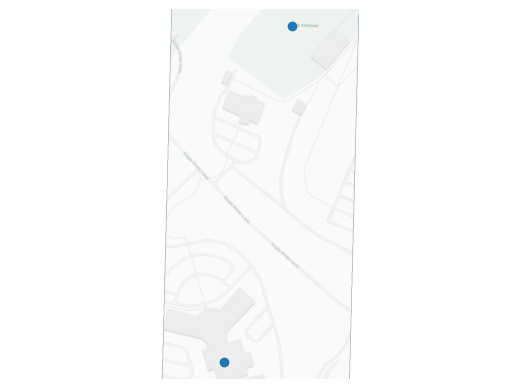

In [ ]:
ax = addresses_c[addresses_c['COMBINED_ADDR'] == '2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129'].plot()
cx.add_basemap(ax, crs=addresses_raw.crs, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_adjustable('datalim')
ax.set_axis_off()

In [185]:
addresses_c[addresses_c['COMBINED_ADDR'] == '2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129'].iloc[:, 22:]

,EDIT_DATE,EDIT_USER,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT
FEATURE_KE,,,,,,,,,,,,
533858,2021-02-16,t096517,EAMS,DUP,2005 EAGLE RIDGE DR,None,0.0,0.0,POINT (1343238.652 359928.177),2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129,2005 EAGLE RIDGE DR,2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129
612791,2023-04-28,T096517,EAMS,DUP,2005 EAGLE RIDGE DR,None,0.0,0.0,POINT (1343519.572 361307.99),2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129,2005 EAGLE RIDGE DR,2005 EAGLE RIDGE DR SOUTH PARK TOWNSHIP 15129


#### Batch geocoding

As a fallback for complex/ambiguous duplication cases, it may be simplest to use a general-purpose geocoding library.

In [186]:
addr_dupe_geo_drop = addr_dupe_geo.drop_duplicates(subset='COMBINED_ADDR')
len(addr_dupe_geo_drop)

645

In [ ]:
# exporting for use in geocode.ipynb
addr_dupe_geo_drop.to_csv('data/processing/AddressPoints_dupes.csv')

In [ ]:
# importing geocoded entries
addr_dupe_geo_corrected = geopandas.read_file('data/processing/AddressPoints_dupes_geocoded.geojson')
addr_dupe_geo_corrected = addr_dupe_geo_corrected.set_index('FEATURE_KE')

In [227]:
addr_dupe_geo_corrected.iloc[:3, -4:]

,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT,geometry
FEATURE_KE,,,,
2866,51 BOUNDARY ST CITY OF PITTSBURGH 15213,51 BOUNDARY ST,51 BOUNDARY ST CITY OF PITTSBURGH 15213,POINT (-79.95062 40.43902)
4022,2201 SALISBURY ST CITY OF PITTSBURGH 15210,2201 SALISBURY ST,2201 SALISBURY ST CITY OF PITTSBURGH 15210,POINT (-79.97542 40.41928)
5664,1700 WASHINGTON BLVD PORT VUE BOROUGH 15133,1700 WASHINGTON BLVD,1700 WASHINGTON BLVD PORT VUE BOROUGH 15133,POINT (-79.88127 40.33201)


In [230]:
addr_dupe_geo_corrected = addr_dupe_geo_corrected.to_crs(addresses_c.crs)
addr_dupe_geo_corrected.iloc[:3, -4:]

,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT,geometry
FEATURE_KE,,,,
2866,51 BOUNDARY ST CITY OF PITTSBURGH 15213,51 BOUNDARY ST,51 BOUNDARY ST CITY OF PITTSBURGH 15213,POINT (1356023.717 410417.787)
4022,2201 SALISBURY ST CITY OF PITTSBURGH 15210,2201 SALISBURY ST,2201 SALISBURY ST CITY OF PITTSBURGH 15210,POINT (1348939.168 403404.945)
5664,1700 WASHINGTON BLVD PORT VUE BOROUGH 15133,1700 WASHINGTON BLVD,1700 WASHINGTON BLVD PORT VUE BOROUGH 15133,POINT (1374378.008 370972.095)


In [207]:
# dropping duplicate features from dataframe
addresses_c = addresses_c.drop(addr_dupe_geo.index)

In [242]:
# re-appending features with correct geocoding
addresses_c = pd.concat([addresses_c, addr_dupe_geo_corrected])

In [ ]:
# verifying concatenation
addresses_c.loc[addr_dupe_geo_corrected.index].head()

,ADDRESS_ID,PARENT_ID,STREET_ID,ADDRESS_TY,STATUS,ADDR_NUM_P,ADDR_NUM,ADDR_NUM_S,ST_PREMODI,ST_PREFIX,...,SOURCE,EXP_FLAG,FULL_ADDRE,ST_SUFFIX,POINT_X,POINT_Y,geometry,COMBINED_ADDR,FULL_ADDR_NOUNIT,COMBINED_ADDR_NOUNIT
FEATURE_KE,,,,,,,,,,,,,,,,,,,,,
2866,2866,0,3026,1,ACTIVE,None,51,None,None,None,...,DRE,DUP,51 BOUNDARY ST,None,0.0,0.0,POINT (1356023.717 410417.787),51 BOUNDARY ST CITY OF PITTSBURGH 15213,51 BOUNDARY ST,51 BOUNDARY ST CITY OF PITTSBURGH 15213
4022,4022,0,20932,1,ACTIVE,None,2201,None,None,None,...,EAMS,DUP,2201 SALISBURY ST,None,0.0,0.0,POINT (1348939.168 403404.945),2201 SALISBURY ST CITY OF PITTSBURGH 15210,2201 SALISBURY ST,2201 SALISBURY ST CITY OF PITTSBURGH 15210
5664,5664,0,25207,2,ACTIVE,None,1700,None,None,None,...,EAMS,DUP,1700 WASHINGTON BLVD,None,0.0,0.0,POINT (1374378.008 370972.095),1700 WASHINGTON BLVD PORT VUE BOROUGH 15133,1700 WASHINGTON BLVD,1700 WASHINGTON BLVD PORT VUE BOROUGH 15133
5688,5688,0,8913,1,ACTIVE,None,1309,None,None,None,...,EAMS,DUP,1309 FREEPORT RD,None,0.0,0.0,POINT (1395651.582 446516.791),1309 FREEPORT RD HARMAR TOWNSHIP 15024,1309 FREEPORT RD,1309 FREEPORT RD HARMAR TOWNSHIP 15024
6902,6902,0,10303,1,ACTIVE,None,298,None,None,None,...,DRE,DUP,298 HARMONY RD,None,0.0,0.0,POINT (1317492.906 441523.556),298 HARMONY RD KILBUCK TOWNSHIP 15237,298 HARMONY RD,298 HARMONY RD KILBUCK TOWNSHIP 15237


In [251]:
# verifying all addresses are now unique
len(addresses_c) == addresses_c['COMBINED_ADDR'].nunique()

True

## Export

In [ ]:
addresses_c.to_file('data/processing/AddressPoints_clean.shp.zip')

/var/folders/zj/02jlcxcn1dz5jm6ct_f_4wrr0000gn/T/ipykernel_85485/2058729956.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  addresses_c.to_file('data/AddressPoints_clean.shp.zip')
/opt/anaconda3/envs/dsa_py/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field EDIT_DATE create as date field, though DateTime requested.
  ogr_write(
/opt/anaconda3/envs/dsa_py/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'COMBINED_ADDR' to 'COMBINED_A'
  ogr_write(
/opt/anaconda3/envs/dsa_py/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'FULL_ADDR_NOUNIT' to 'FULL_ADDR_'
  ogr_write(
/opt/anaconda3/envs/dsa_py/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'COMBINED_ADDR_NOUNIT' to 'COMBINED_1'
  ogr_write(
